In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from multitask_sparse_parity import MultitaskSparseParityDataset, MultitaskSparseParityModel
from storer import Storer
import seaborn as sns
import torch
import einops

In [2]:
# d_mlp = 16
storer = Storer("/modal_volume/mtsp_results/metrics/")
storer.add_datestamp_prefix()


# from train_mtsp_model_and_not_not import TrainConfig, AndNotNotDataset

# storer.add_prefix(f"train_mtsp_model_and_not_not/v1/")

from train_mtsp_model_uniform_task_distribution_modal import TrainConfig

storer.add_prefix(f"train_mtsp_model_uniform_task_distribution/v10/")

config = TrainConfig()


# storer.add_prefix(f"train_mtsp_model_uniform_task_distribution/v10/{config.cache_key()}")


storer.add_prefix(f"{config.cache_key()}")

torch.manual_seed(config.seed)
model = MultitaskSparseParityModel(
    d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
)
dataset = MultitaskSparseParityDataset(
    n_control_bits=config.n_control_bits,
    n_task_bits=config.n_task_bits,
    n_xored_bits=config.n_xored_bits,
    task_distribution_decay_rate=config.task_distribution_decay_rate,
    batch_sz=config.batch_sz,
    size=config.steps,
)

# dataset = AndNotNotDataset(
#     n_control_bits=config.n_control_bits,
#     n_task_bits=config.n_task_bits,
#     n_xored_bits=config.n_xored_bits,
#     task_distribution_decay_rate=config.task_distribution_decay_rate,
#     batch_sz=config.batch_sz,
#     size=config.steps,
# )
storer.add_prefix(f"model/{config.steps}")
key = "model"
assert storer.exists(key), storer
model.load_state_dict(storer.read(key))
losses_by_step_and_task: np.ndarray = storer.read("losses_by_step_and_task")

torch.manual_seed(0)
task_ids, task_bits, parity = dataset.get_batch(batch_sz=1024)
logits = model((task_ids, task_bits, ()))
# val_loss = F.cross_entropy(logits, parity)
val_loss = F.binary_cross_entropy_with_logits(-logits, parity.float())
print(val_loss)

/Users/jack/Desktop/Jack/tests/mats-9/scaling/spd-multitasksparseparity/spd/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor(2.7383e-08, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [93]:
F.binary_cross_entropy_with_logits(-logits, parity.float())

tensor(2.7383e-08, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)

In [96]:
logits * (parity * 2 - 1)

tensor([-16.1996, -17.8479, -16.8722,  ..., -16.3615, -16.7607, -16.6556],
       grad_fn=<MulBackward0>)

In [107]:
torch.log(torch.exp(logits * (parity * 2 - 1)) + torch.exp(torch.tensor(1)))

tensor([1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
       grad_fn=<LogBackward0>)

In [126]:
logits * (parity * 2 - 1) + torch.logsumexp(torch.stack((logits * (parity * -2 + 1), torch.exp(torch.ones_like(logits)))), dim=0)

tensor([1.9073e-06, 0.0000e+00, 0.0000e+00,  ..., 1.9073e-06, 0.0000e+00,
        0.0000e+00], grad_fn=<AddBackward0>)

In [123]:
torch.stack((logits * (parity * -2 + 1), torch.exp(torch.ones_like(logits))))

tensor([[16.1996, 17.8479, 16.8722,  ..., 16.3615, 16.7607, 16.6556],
        [ 2.7183,  2.7183,  2.7183,  ...,  2.7183,  2.7183,  2.7183]],
       grad_fn=<StackBackward0>)

In [106]:
torch.exp(logits *  (parity * 2 - 1))

tensor([9.2172e-08, 1.7732e-08, 4.7043e-08,  ..., 7.8396e-08, 5.2590e-08,
        5.8422e-08], grad_fn=<ExpBackward0>)

In [105]:
(parity * 2 - 1)

tensor([-1, -1,  1,  ...,  1, -1,  1])

In [104]:
parity

tensor([0, 0, 1,  ..., 1, 0, 1])

In [103]:
logits

tensor([ 16.1996,  17.8479, -16.8722,  ..., -16.3615,  16.7607, -16.6556],
       grad_fn=<SqueezeBackward1>)

In [3]:
dataset.selected_bits_by_task

tensor([[ 7, 17],
        [22, 26]])

In [4]:
def patch_in_l2_if_model_has_l2_fix(model):
    if hasattr(model, "l2_fix"):
        model.l2 = nn.Linear(model.d_mlp, 2)
        model.l2.weight.data = torch.stack([model.l2_fix, -model.l2_fix])

In [5]:
patch_in_l2_if_model_has_l2_fix(model)

In [6]:
if hasattr(model, "l2_bce"):
    l2_synth = model.l2_bce.weight.data[0]
else:
    l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

In [7]:
model

MultitaskSparseParityModel(
  (l1): Linear(in_features=32, out_features=12, bias=False)
  (l2_bce): Linear(in_features=12, out_features=1, bias=False)
)

In [8]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum(), (neuron_mask).sum()

(tensor(0), tensor(12))

In [9]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [10]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
# x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x1 = torch.cat([torch.ones_like(task_ids).unsqueeze(1), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([15.0727, 15.2888, 15.2888, 15.5050])

In [11]:
task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[0]] = bits
out = model((task_ids, task_bits, ()))
# out[:, 0] - out[:, 1]

In [12]:
torch.ones_like(task_ids)

tensor([1, 1, 1, 1])

In [13]:
x1

tensor([[1., 0., 0.],
        [1., 1., 0.],
        [1., 0., 1.],
        [1., 1., 1.]])

In [14]:
F.binary_cross_entropy_with_logits(x4, ((1 + bits.sum(-1)) % 2).float())

tensor(7.6444)

<Axes: >

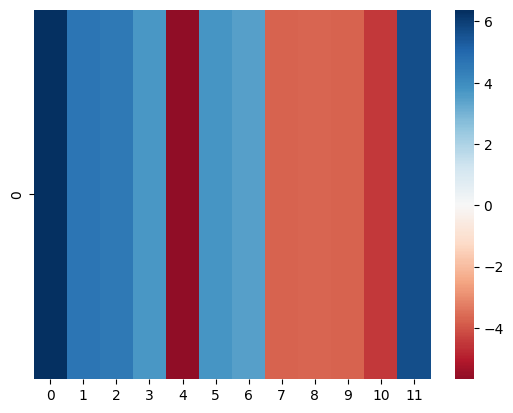

In [15]:
sns.heatmap((l2_synth[neuron_mask])[None], cmap="RdBu", center=0)

()

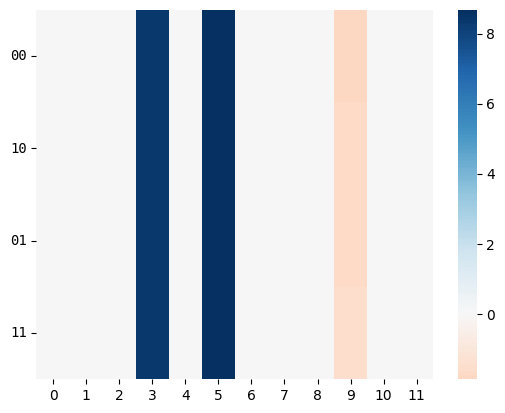

In [16]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

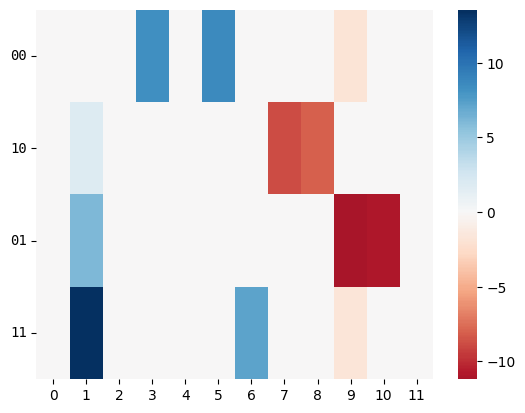

In [17]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[0]] = bits
# out = model((task_ids, task_bits, ()))
# out[:, 0] - out[:, 1]

x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
# x4 = model.l2(x3)
x4 = model.l2_bce(x3)
x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

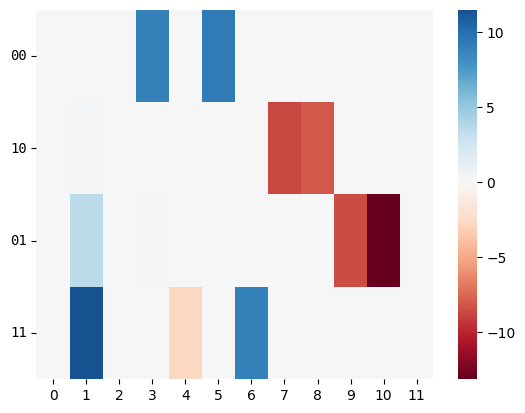

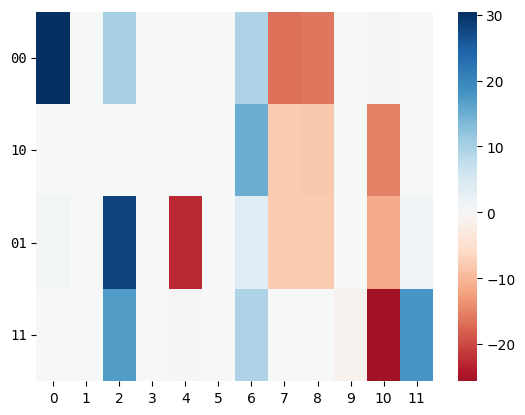

In [18]:
for task_id in range(config.n_control_bits):
    task_ids = torch.tensor(task_id).repeat(2**config.n_xored_bits)
    # task_bits = torch.ones((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
    # task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits))
    task_bits = torch.randint(2, (2**config.n_xored_bits, config.n_task_bits)).float()
    task_bits[:, dataset.selected_bits_by_task[task_id]] = bits.float()
    # out = model((task_ids, task_bits, ()))
    # out[:, 0] - out[:, 1]

    x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
    x2 = model.l1(x1)
    x3 = F.relu(x2)
    x4 = model.l2_bce(x3)
    x1 = x1.detach()
    x2 = x2.detach()
    x3 = x3.detach()
    x4 = x4.detach()

    bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
    ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
    ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
    ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
    plt.show()

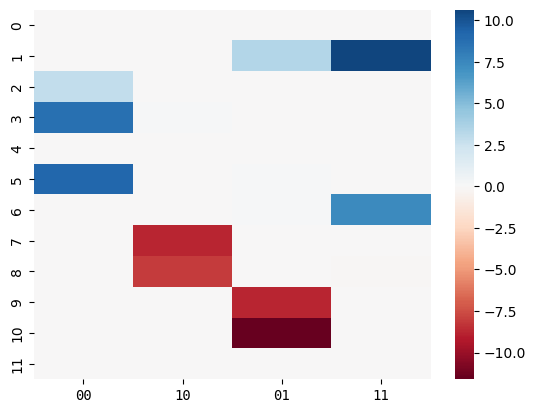

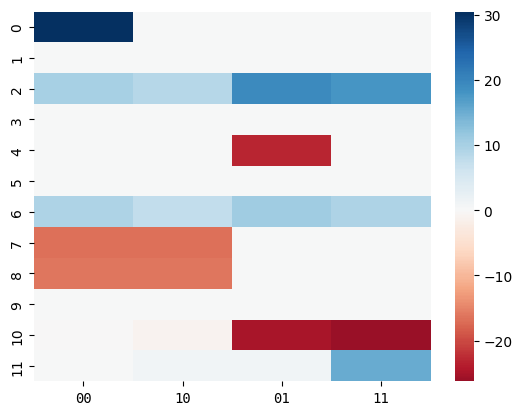

In [19]:
for task_id in range(config.n_control_bits):
    task_ids = torch.tensor(task_id).repeat(2**config.n_xored_bits)
    # task_bits = torch.ones((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
    # task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits))
    task_bits = torch.randint(2, (2**config.n_xored_bits, config.n_task_bits)).float()
    task_bits[:, dataset.selected_bits_by_task[task_id]] = bits.float()
    # out = model((task_ids, task_bits, ()))
    # out[:, 0] - out[:, 1]

    x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
    x2 = model.l1(x1)
    x3 = F.relu(x2)
    x4 = model.l2_bce(x3)
    x1 = x1.detach()
    x2 = x2.detach()
    x3 = x3.detach()
    x4 = x4.detach()

    bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
    ax = sns.heatmap((x3 * l2_synth[neuron_mask]).T, cmap="RdBu", center=0)
    ax.set_xticks(np.arange(len(bit_labels)) + 0.5)
    ax.set_xticklabels(bit_labels, rotation=0, fontfamily="monospace")
    plt.show()

## almost linear neuron merge - unfinished

In [20]:
# almost_linear_neuron_idxs = []

# for i in range(model.d_mlp):
#     if (model.l1.weight[i][config.n_control_bits :] >= 0).all() and (
#         model.l1.weight[i][: config.n_control_bits].min()
#         > -model.l1.weight[2][config.n_control_bits :].max()
#     ):
#         almost_linear_neuron_idxs.append(i)
# almost_linear_neuron_idxs = torch.tensor(almost_linear_neuron_idxs)
# almost_linear_neuron_idxs

In [21]:
# #unfinished, was working 2026.03.13 on merging together some

# non_linear_neurons_mask = torch.ones((model.d_mlp,)).bool()
# non_linear_neurons_mask[almost_linear_neuron_idxs] = False

# merged_d_mlp = model.d_mlp - almost_linear_neuron_idxs.size(0) + 1

# l1_weights_with_almost_linear_neurons_merged = torch.zeros(
#     (merged_d_mlp, model.l1.weight.data.size(1))
# )
# # l1_weights_with_almost_linear_neurons_merged[0] = model.l1.weight.data[
# #     almost_linear_neuron_idxs
# # ].sum(0)

# l1_weights_with_almost_linear_neurons_merged[0] = model.l1.weight.data[
#     almost_linear_neuron_idxs
# ] * l2_synth[almost_linear_neuron_idxs].unsqueeze(1)
# l1_weights_with_almost_linear_neurons_merged[1:] = model.l1.weight.data[non_linear_neurons_mask]
# l2_synth_with_almost_linear_neurons_merged = torch.zeros((merged_d_mlp,))
# l2_synth_with_almost_linear_neurons_merged[0] = l2_synth[almost_linear_neuron_idxs].sum(0)
# # l2_synth_with_almost_linear_neurons_merged[0] = torch.tensor(1)

# l2_synth_with_almost_linear_neurons_merged[1:] = l2_synth[non_linear_neurons_mask]



In [22]:
# model.l1.weight.data[almost_linear_neuron_idxs] * l2_synth[almost_linear_neuron_idxs].unsqueeze(1)

In [23]:
# l2_synth[almost_linear_neuron_idxs].unsqueeze(0)

In [24]:
# # x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
# # x2 = model.l1(x1)
# # x3 = F.relu(x2)
# # x4 = model.l2(x3)
# # x1 = x1.detach()
# # x2 = x2.detach()
# # x3 = x3.detach()
# # x4 = x4.detach()
# # # F.cross_entropy(x4, (bits.sum(-1) % 2).long())

# x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits).float(), task_bits.float()], dim=1)
# x2 = model.l1(x1)
# x3 = F.relu(x2)
# x4 = x3 @ l2_synth.T
# x1 = x1.detach()
# x2 = x2.detach()
# x3 = x3.detach()
# x4 = x4.detach()


# # x2 = x1 @ l1_weights_with_almost_linear_neurons_merged.T
# # x3 = F.relu(x2)
# # x4 = x3 @ l2_synth_with_almost_linear_neurons_merged.T
# # x1 = x1.detach()
# # x2 = x2.detach()
# # x3 = x3.detach()
# # x4 = x4.detach()
# # F.binary_cross_entropy_with_logits(x4, (bits.sum(-1) % 2).float())
# x4

In [25]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0]

In [26]:
F.relu(x1 @ model.l1.weight.data.T)[0]

tensor([4.7688, 0.0000, 2.2494, 0.0000, 0.0000, 0.0000, 2.6398, 4.4403, 4.3658,
        0.0000, 0.0610, 0.0000])

In [27]:
# F.relu(
#     x1 @ l1_weights_with_almost_linear_neurons_merged.T
# ) @ l2_synth_with_almost_linear_neurons_merged.T

In [28]:
# F.relu(input=x1 @ model.l1.weight.data.T)[0, non_linear_neurons_mask]

In [29]:
# F.relu(input=x1 @ model.l1.weight.data.T)[0]

In [30]:
# q = torch.cat(
#     (
#         F.relu(input=x1 @ model.l1.weight.data.T)[0][almost_linear_neuron_idxs].sum(0).unsqueeze(0),
#         F.relu(input=x1 @ model.l1.weight.data.T)[0][non_linear_neurons_mask],
#     )
# )

In [31]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0] - q

In [32]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0]

In [33]:
# l1_weights_with_almost_linear_neurons_merged[0]

In [34]:
# model.l1.weight.data[almost_linear_neuron_idxs]

In [35]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0][almost_linear_neuron_idxs].sum()

In [36]:
# F.relu(input=x1 @ model.l1.weight.data.T) @ l2_synth.T

In [37]:
# x2[0]

In [38]:
# F.relu(
#     x1 @ l1_weights_with_almost_linear_neurons_merged.T
# ) @ l2_synth_with_almost_linear_neurons_merged.T

In [39]:
# l2_synth

In [40]:
# l2_synth_with_almost_linear_neurons_merged

In [41]:
# F.relu(x2[0]).sum()

In [42]:
# F.relu(x1 @ l1_weights_with_almost_linear_neurons_merged.T)[0].sum()

In [43]:
#

In [44]:
# F.relu(
#     x1 @ l1_weights_with_almost_linear_neurons_merged.T
# ) @ l2_synth_with_almost_linear_neurons_merged.T

In [45]:
# x4

In [46]:
# x3.shape, l2_synth_with_almost_linear_neurons_merged.shape

In [47]:
# x1.shape, x2.shape

In [48]:
#

In [49]:
# x2.shape

In [50]:
# task_bits

In [51]:
#

In [52]:
# x4

In [53]:
# sns.heatmap(l1_weights_with_almost_linear_neurons_merged, cmap="RdBu", center=0)

## .

<Axes: >

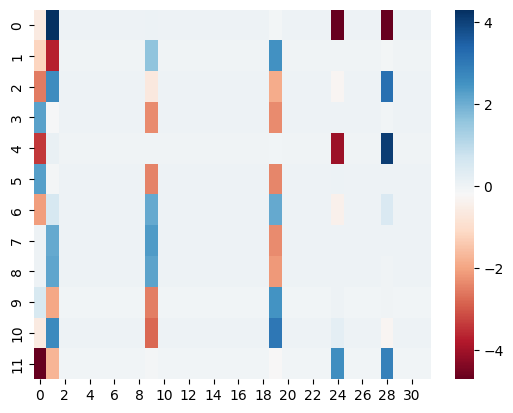

In [54]:
sns.heatmap(model.l1.weight.data, cmap="RdBu")

In [55]:
(x3 * l2_synth[neuron_mask])[:, [2, 7, 8]].sum(1)

tensor([-22.5019, -24.2997,  19.2197,  17.8662])

In [56]:
k = config.n_xored_bits + config.n_control_bits

bits_all = (
    torch.floor(torch.arange(2 ** (k)).unsqueeze(1) / (2 ** (k - 1 - torch.arange((k))))) % 2
).long()

In [57]:
bits_all.shape

torch.Size([16, 4])

()

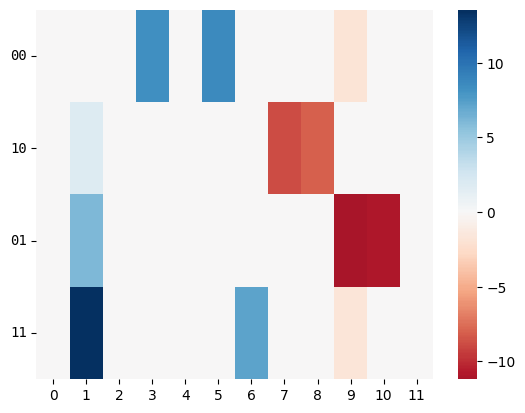

In [58]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
task_bits = torch.zeros((2**config.n_xored_bits, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[0]] = bits
# out = model((task_ids, task_bits, ()))
# out[:, 0] - out[:, 1]

x1 = torch.cat([F.one_hot(task_ids, config.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2_bce(x3)
x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

In [59]:
(
    torch.randn((config.n_control_bits, config.n_task_bits))
    .sort()
    .indices[:, : config.n_xored_bits]
    .sort()
    .values
)

tensor([[ 9, 11],
        [17, 26]])

In [60]:
# x1[5]

In [61]:
# model.l1(x1)[5, 1]

In [62]:
# (model.l1.weight.data[1] * x1[5]).sum()
# (model.l1.weight.data[1] * x1[5])

In [63]:
# model.l1.weight.data[1]

In [64]:
# x3[5]

<Axes: >

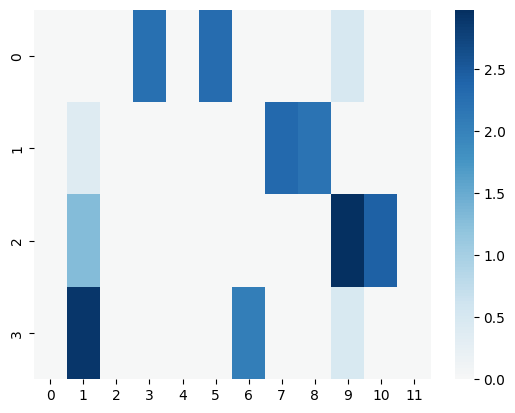

In [65]:
sns.heatmap(x3, cmap="RdBu", center=0)

In [66]:
# (x3 * l2_synth[neuron_mask])[7]

In [67]:
x4

tensor([[ 15.0727],
        [-15.0633],
        [-16.1505],
        [ 18.9047]])

()

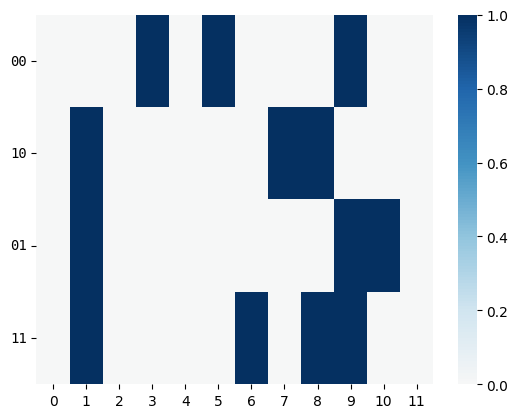

In [68]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x2 > 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

<Axes: >

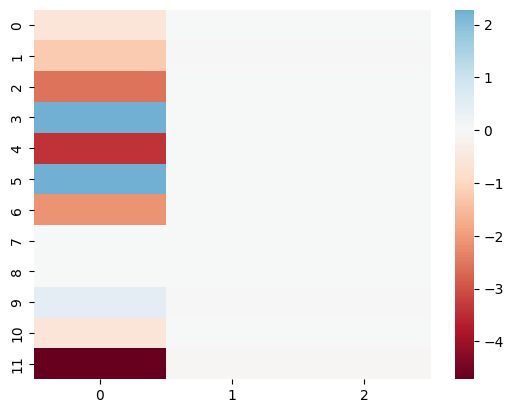

In [69]:
##
sns.heatmap(data=l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

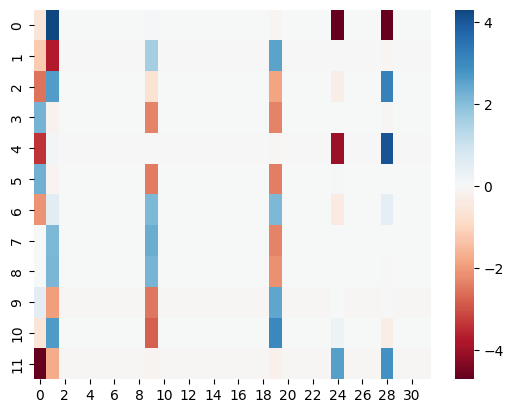

In [70]:
sns.heatmap(data=model.l1.weight.data, cmap="RdBu", center=0)

In [71]:
l2_synth[neuron_mask]

tensor([ 6.3854,  4.6873,  4.5741,  3.7036, -5.6786,  3.7794,  3.4891, -3.7604,
        -3.6862, -3.7575, -4.4953,  5.6390])

In [72]:
neuron_mask = ~(l2_synth.abs() < 0.03)

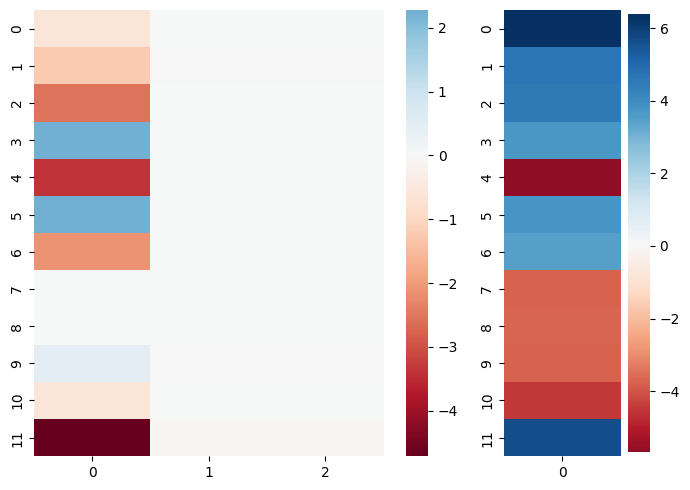

In [73]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(data=l1_for_task0[neuron_mask], cmap="RdBu", center=0, ax=ax1)
sns.heatmap(data=l2_synth[neuron_mask].unsqueeze(1), cmap="RdBu", center=0, ax=ax2)
plt.tight_layout()

In [74]:
dataset.selected_bits_by_task

tensor([[ 7, 17],
        [22, 26]])

In [75]:
# l1_for_tasks = model.l1.weight.data[:, dataset.selected_bits_by_task.sort(1).values.reshape(-1)]

In [76]:
input_idxs = torch.cat(
    (
        torch.arange(config.n_control_bits).unsqueeze(1),
        dataset.selected_bits_by_task.sort(1).values,
    ),
    dim=1,
)
l1_for_tasks = model.l1.weight.data[:, input_idxs.reshape(-1)]
input_idxs

tensor([[ 0,  7, 17],
        [ 1, 22, 26]])

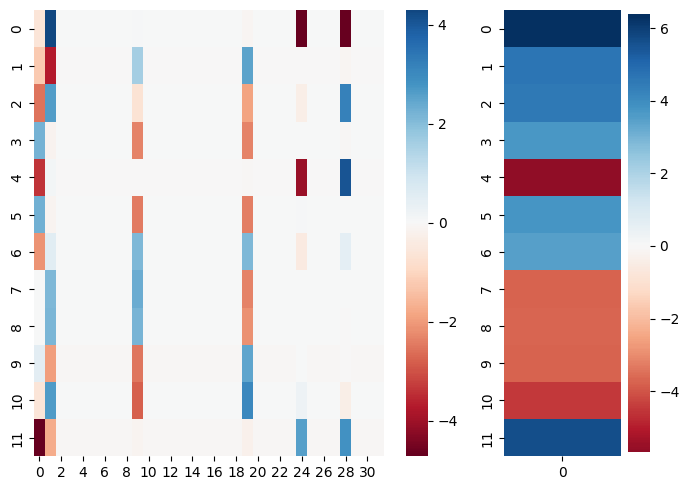

In [77]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(data=model.l1.weight.data, cmap="RdBu", center=0, ax=ax1)
# sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
sns.heatmap(data=l2_synth[neuron_mask].unsqueeze(1), cmap="RdBu", center=0, ax=ax2)
plt.tight_layout()

In [78]:
rows = model.l1.weight.data
n_cols = rows[0].shape[0]
print("      " + "".join(f"{'col' + str(j):>6}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:6.2f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

        col0  col1  col2  col3  col4  col5  col6  col7  col8  col9 col10 col11 col12 col13 col14 col15 col16 col17 col18 col19 col20 col21 col22 col23 col24 col25 col26 col27 col28 col29 col30 col31
row0   -0.60  4.29  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.04  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03  0.03 -0.07  0.03  0.03  0.03  0.03 -4.72  0.03  0.03  0.03 -4.69  0.03  0.03  0.03
row1   -1.22 -3.73 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03  1.61 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03  2.51 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.03 -0.09 -0.03 -0.03 -0.03
row2   -2.54  2.63  0.02  0.02  0.02  0.02  0.02  0.02  0.02 -0.67  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02  0.02 -1.87  0.02  0.02  0.02  0.02 -0.32  0.02  0.02  0.02  3.17  0.02  0.02  0.02
row3    2.25 -0.17  0.01  0.01  0.01  0.01  0.01  0.01  0.01 -2.35  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01  0.01 -2.33  0.01  0.01  0.01  0.01  0.02  0.01  0.01  0.01 -0.06  0.01  0.01  0.01
row4 

In [79]:
dataset.selected_bits_by_task

tensor([[ 7, 17],
        [22, 26]])

In [80]:
neuron_mask = torch.ones_like(neuron_mask).bool()

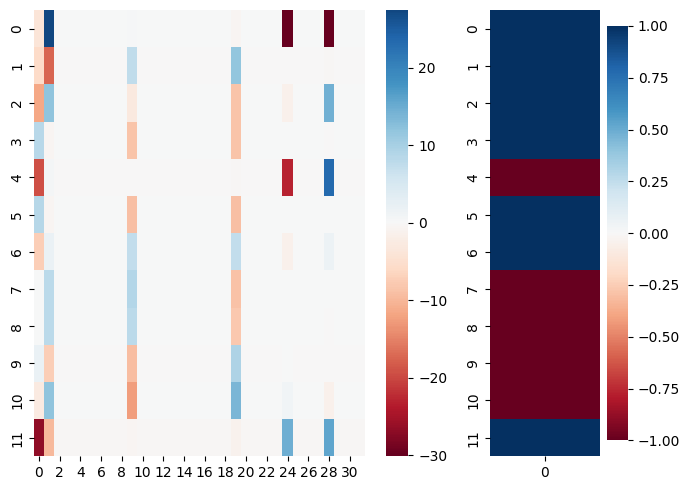

In [81]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(
    data=model.l1.weight.data * l2_synth[neuron_mask].abs().unsqueeze(1),
    cmap="RdBu",
    center=0,
    ax=ax1,
)
# sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
sns.heatmap(
    data=(l2_synth[neuron_mask].unsqueeze(1) > 0).float() * 2 - 1, cmap="RdBu", center=0, ax=ax2
)
plt.tight_layout()

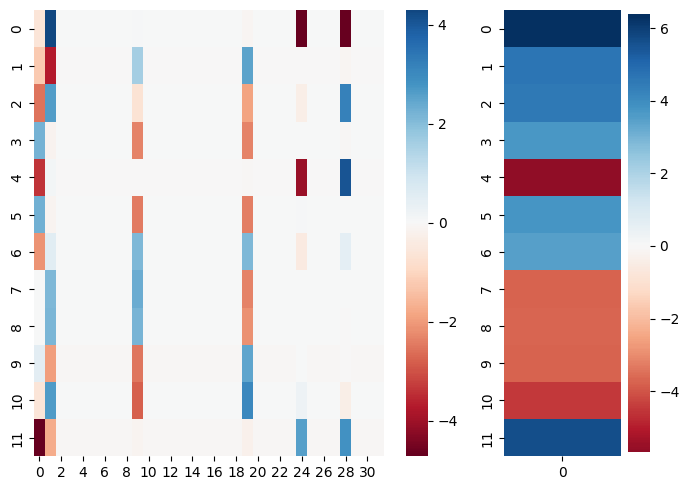

In [82]:
n_cols_left = l1_for_task0[neuron_mask].shape[1]
n_cols_right = 1

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
)
sns.heatmap(
    data=model.l1.weight.data,
    cmap="RdBu",
    center=0,
    ax=ax1,
)
# sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
sns.heatmap(data=l2_synth[neuron_mask].unsqueeze(1), cmap="RdBu", center=0, ax=ax2)
plt.tight_layout()

In [83]:
import os

In [84]:
dataset.selected_bits_by_task

tensor([[ 7, 17],
        [22, 26]])

In [85]:
save_weight_step_paths = sorted(
    [x for x in os.listdir(storer.root_path) if x.startswith("step=")],
    key=lambda x: int(x[len("step=") :]),
)

In [86]:
# don't normalise by l2
for save_weight_step_path in save_weight_step_paths[:1000]:
    os.makedirs(
        f"./plots/mtsp_weights_over_training/v5/{config.cache_key()}/do-not-normalise-by-l2",
        exist_ok=True,
    )
    model = MultitaskSparseParityModel(
        d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
    )
    # save_weight_step_path = save_weight_step_paths[-1]
    model.load_state_dict(storer.read(save_weight_step_path + "/model"))
    patch_in_l2_if_model_has_l2_fix(model)
    # l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]
    l2_synth = model.l2_bce.weight.data[0]

    n_cols_left = model.l1.weight.data[neuron_mask].shape[1]
    n_cols_right = 1

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
    )
    sns.heatmap(
        data=model.l1.weight.data,
        cmap="RdBu",
        center=0,
        ax=ax1,
    )
    # sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
    sns.heatmap(data=l2_synth[neuron_mask].unsqueeze(1), cmap="RdBu", center=0, ax=ax2)
    plt.tight_layout()
    plt.savefig(
        f"./plots/mtsp_weights_over_training/v5/{config.cache_key()}/do-not-normalise-by-l2/{save_weight_step_path}.png"
    )
    plt.close(fig)

In [87]:
for save_weight_step_path in save_weight_step_paths[:1000]:
    os.makedirs(
        f"./plots/mtsp_weights_over_training/v5/{config.cache_key()}/normalise-by-l2", exist_ok=True
    )
    model = MultitaskSparseParityModel(
        d_mlp=config.d_mlp, n_control_bits=config.n_control_bits, n_task_bits=config.n_task_bits
    )
    # save_weight_step_path = save_weight_step_paths[-1]
    model.load_state_dict(storer.read(save_weight_step_path + "/model"))
    patch_in_l2_if_model_has_l2_fix(model)
    # l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]
    l2_synth = model.l2_bce.weight.data[0]

    n_cols_left = model.l1.weight.data[neuron_mask].shape[1]
    n_cols_right = 1

    fig, (ax1, ax2) = plt.subplots(
        1, 2, figsize=(7, 5), gridspec_kw={"width_ratios": [n_cols_left, n_cols_right]}
    )
    sns.heatmap(
        data=model.l1.weight.data * l2_synth[neuron_mask].abs().unsqueeze(1),
        cmap="RdBu",
        center=0,
        ax=ax1,
    )
    # sns.heatmap(data=l1_for_tasks, cmap="RdBu", center=0, ax=ax1)
    sns.heatmap(
        data=(l2_synth[neuron_mask].unsqueeze(1) > 0).float() * 2 - 1, cmap="RdBu", center=0, ax=ax2
    )
    plt.tight_layout()
    plt.savefig(
        f"./plots/mtsp_weights_over_training/v5/{config.cache_key()}/normalise-by-l2/{save_weight_step_path}.png"
    )
    plt.close(fig)

In [88]:
rows = model.l1.weight.data * l2_synth[neuron_mask].abs().unsqueeze(1)
n_cols = rows[0].shape[0]
print("      " + "".join(f"{'col' + str(j):>6}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:6.1f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

        col0  col1  col2  col3  col4  col5  col6  col7  col8  col9 col10 col11 col12 col13 col14 col15 col16 col17 col18 col19 col20 col21 col22 col23 col24 col25 col26 col27 col28 col29 col30 col31
row0    -3.8  27.4   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.3   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2   0.2  -0.5   0.2   0.2   0.2   0.2 -30.1   0.2   0.2   0.2 -29.9   0.2   0.2   0.2
row1    -5.7 -17.5  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1   7.5  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  11.8  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.1  -0.4  -0.1  -0.1  -0.1
row2   -11.6  12.0   0.1   0.1   0.1   0.1   0.1   0.1   0.1  -3.1   0.1   0.1   0.1   0.1   0.1   0.1   0.1   0.1   0.1  -8.5   0.1   0.1   0.1   0.1  -1.5   0.1   0.1   0.1  14.5   0.1   0.1   0.1
row3     8.3  -0.6   0.0   0.0   0.0   0.0   0.0   0.0   0.0  -8.7   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0   0.0  -8.6   0.0   0.0   0.0   0.0   0.1   0.0   0.0   0.0  -0.2   0.0   0.0   0.0
row4 

In [89]:
l2_synth[neuron_mask]

tensor([ 6.3854,  4.6873,  4.5741,  3.7036, -5.6786,  3.7794,  3.4891, -3.7604,
        -3.6862, -3.7575, -4.4953,  5.6390])

In [90]:
rows = l1_for_tasks[neuron_mask]
n_cols = rows[0].shape[0]
print("o7 = original idx is 7")
print(
    "      "
    + "".join(
        f"{'col' + str(j) + ' o' + str(input_idxs.reshape(-1)[j].item()):>10}"
        for j in range(n_cols)
    )
)
# print("      " + "".join(f"{'col' + str(j):>10}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:10.4f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

o7 = original idx is 7
         col0 o0   col1 o7  col2 o17   col3 o1  col4 o22  col5 o26
row0     -0.5998    0.0310    0.0310    4.2931    0.0310    0.0310
row1     -1.2239   -0.0298   -0.0298   -3.7305   -0.0298   -0.0298
row2     -2.5395    0.0212    0.0212    2.6256    0.0212    0.0212
row3      2.2469    0.0083    0.0083   -0.1728    0.0083    0.0083
row4     -3.4111   -0.0085   -0.0085    0.1174   -0.0085   -0.0085
row5      2.2814    0.0078    0.0078   -0.1368    0.0078    0.0078
row6     -2.1010    0.0022    0.0022    0.5302    0.0022    0.0022
row7     -0.0000   -0.0000    0.0000    2.1035    0.0000    0.0000
row8     -0.0000    0.0000    0.0000    2.1753    0.0000    0.0000
row9      0.4980   -0.0415   -0.0415   -1.9649   -0.0415   -0.0415
row10    -0.6150    0.0144    0.0144    2.6501    0.0144    0.0144
row11    -4.7170   -0.0509   -0.0509   -1.7361   -0.0509   -0.0509


In [91]:
rows = l1_for_task0[neuron_mask]
n_cols = rows[0].shape[0]
print("      " + "".join(f"{'col' + str(j):>10}" for j in range(n_cols)))
for i, row in enumerate(rows):
    vals = "".join(f"{v:10.4f}" for v in row.tolist())
    print(f"row{i:<3d}" + vals)

            col0      col1      col2
row0     -0.5998    0.0310    0.0310
row1     -1.2239   -0.0298   -0.0298
row2     -2.5395    0.0212    0.0212
row3      2.2469    0.0083    0.0083
row4     -3.4111   -0.0085   -0.0085
row5      2.2814    0.0078    0.0078
row6     -2.1010    0.0022    0.0022
row7     -0.0000    0.0000    0.0000
row8     -0.0000    0.0000    0.0000
row9      0.4980   -0.0415   -0.0415
row10    -0.6150    0.0144    0.0144
row11    -4.7170   -0.0509   -0.0509


In [92]:
torch.cat((torch.arange(14).unsqueeze(1), l1_for_task0[neuron_mask]), dim=1)

RuntimeError: Sizes of tensors must match except in dimension 1. Expected size 14 but got size 12 for tensor number 1 in the list.

In [ ]:
torch.cat((torch.arange(14), torch.arange(2)), dim=0)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,  0,  1])

In [ ]:
torch.stack

<function torch._VariableFunctionsClass.stack>

In [ ]:
l1_for_task0[neuron_mask].shape

torch.Size([14, 3])

In [ ]:
torch.arange(14).unsqueeze(1).shape

torch.Size([14, 1])

In [ ]:
l1_for_task0[neuron_mask]

tensor([[-1.4754e+00,  9.6294e-02,  9.6533e-02],
        [ 4.3352e-01, -1.7076e-02, -1.7025e-02],
        [-3.4957e-01,  2.1517e-02,  2.1245e-02],
        [ 2.5599e+00,  5.5771e-03,  5.2309e-03],
        [-3.6752e+00,  6.0909e-06,  7.3556e-06],
        [ 2.2073e+00,  5.9563e-03,  5.8437e-03],
        [ 1.4788e+00,  2.9055e-01,  2.8691e-01],
        [-2.6072e-01,  2.7199e-01,  2.6860e-01],
        [ 2.1646e+00,  5.8657e-03,  5.7532e-03],
        [-5.1680e+00, -1.6412e-02, -1.6477e-02],
        [ 4.4636e-01, -8.5155e-03, -9.1769e-03],
        [-1.2267e+00,  2.4083e-02,  2.3919e-02],
        [-1.2279e+00,  2.4182e-02,  2.4013e-02],
        [-4.8924e-04,  5.6850e-05, -1.0558e-03]])

In [ ]:
l1_for_task0[neuron_mask]

tensor([[-1.4754e+00,  9.6294e-02,  9.6533e-02],
        [ 4.3352e-01, -1.7076e-02, -1.7025e-02],
        [-3.4957e-01,  2.1517e-02,  2.1245e-02],
        [ 2.5599e+00,  5.5771e-03,  5.2309e-03],
        [-3.6752e+00,  6.0909e-06,  7.3556e-06],
        [ 2.2073e+00,  5.9563e-03,  5.8437e-03],
        [ 1.4788e+00,  2.9055e-01,  2.8691e-01],
        [-2.6072e-01,  2.7199e-01,  2.6860e-01],
        [ 2.1646e+00,  5.8657e-03,  5.7532e-03],
        [-5.1680e+00, -1.6412e-02, -1.6477e-02],
        [ 4.4636e-01, -8.5155e-03, -9.1769e-03],
        [-1.2267e+00,  2.4083e-02,  2.3919e-02],
        [-1.2279e+00,  2.4182e-02,  2.4013e-02],
        [-4.8924e-04,  5.6850e-05, -1.0558e-03]])

In [ ]:
l2_synth[neuron_mask]

tensor([ 6.3337e+00, -4.7206e+00,  4.1694e+00,  4.1170e+00,  5.4353e+00,
         3.7766e+00, -3.8072e+00,  3.7370e+00,  3.7058e+00,  7.0181e+00,
        -4.6549e+00, -3.5568e+00, -3.5627e+00, -3.1864e-04])

In [ ]:
l1_for_task0[neuron_mask]

tensor([[-1.4754e+00,  9.6294e-02,  9.6533e-02],
        [ 4.3352e-01, -1.7076e-02, -1.7025e-02],
        [-3.4957e-01,  2.1517e-02,  2.1245e-02],
        [ 2.5599e+00,  5.5771e-03,  5.2309e-03],
        [-3.6752e+00,  6.0909e-06,  7.3556e-06],
        [ 2.2073e+00,  5.9563e-03,  5.8437e-03],
        [ 1.4788e+00,  2.9055e-01,  2.8691e-01],
        [-2.6072e-01,  2.7199e-01,  2.6860e-01],
        [ 2.1646e+00,  5.8657e-03,  5.7532e-03],
        [-5.1680e+00, -1.6412e-02, -1.6477e-02],
        [ 4.4636e-01, -8.5155e-03, -9.1769e-03],
        [-1.2267e+00,  2.4083e-02,  2.3919e-02],
        [-1.2279e+00,  2.4182e-02,  2.4013e-02],
        [-4.8924e-04,  5.6850e-05, -1.0558e-03]])

<Axes: >

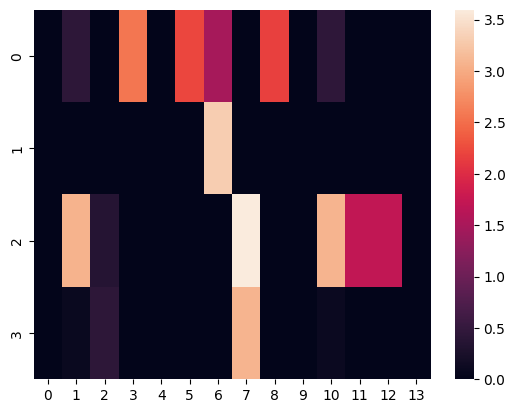

In [ ]:
sns.heatmap(x3)

()

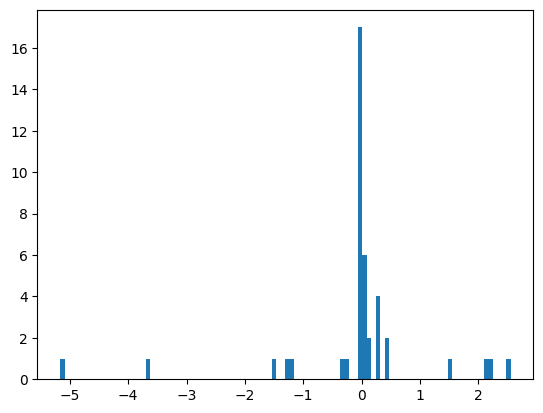

In [ ]:
plt.hist(l1_for_task0[neuron_mask].reshape(-1), bins=100)
()

<Axes: >

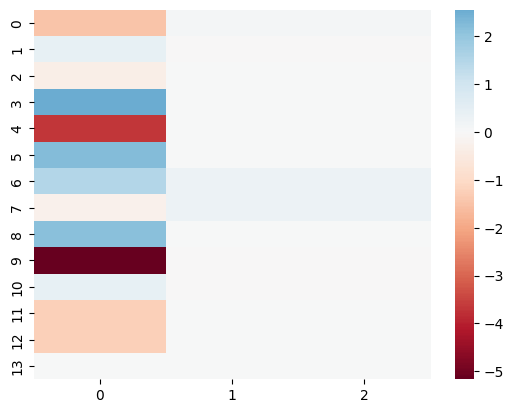

In [ ]:
sns.heatmap(data=l1_for_task0[neuron_mask], cmap="RdBu", center=0)


<Axes: >

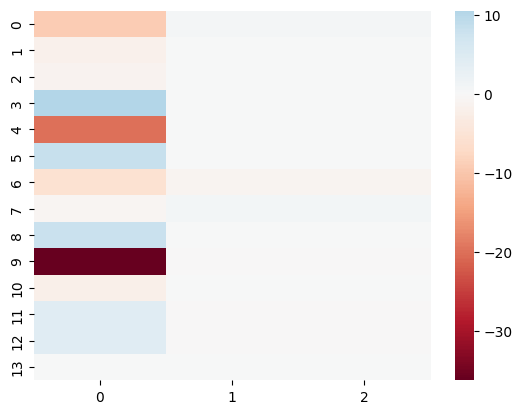

In [ ]:
sns.heatmap(
    (l1_for_task0[neuron_mask] * l2_synth[neuron_mask].unsqueeze(-1)), cmap="RdBu", center=0
)

<Axes: >

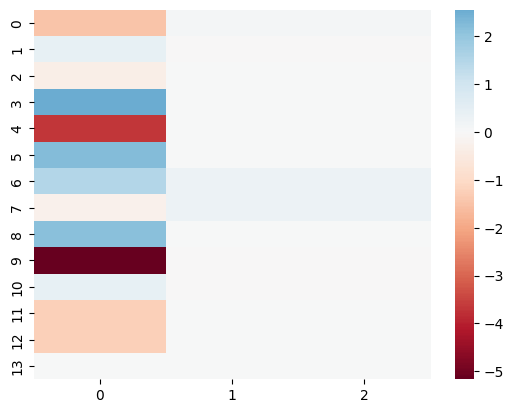

In [ ]:
sns.heatmap((l1_for_task0[neuron_mask]), cmap="RdBu", center=0)

In [ ]:
l1_for_task0[neuron_mask]

tensor([[-1.4754e+00,  9.6294e-02,  9.6533e-02],
        [ 4.3352e-01, -1.7076e-02, -1.7025e-02],
        [-3.4957e-01,  2.1517e-02,  2.1245e-02],
        [ 2.5599e+00,  5.5771e-03,  5.2309e-03],
        [-3.6752e+00,  6.0909e-06,  7.3556e-06],
        [ 2.2073e+00,  5.9563e-03,  5.8437e-03],
        [ 1.4788e+00,  2.9055e-01,  2.8691e-01],
        [-2.6072e-01,  2.7199e-01,  2.6860e-01],
        [ 2.1646e+00,  5.8657e-03,  5.7532e-03],
        [-5.1680e+00, -1.6412e-02, -1.6477e-02],
        [ 4.4636e-01, -8.5155e-03, -9.1769e-03],
        [-1.2267e+00,  2.4083e-02,  2.3919e-02],
        [-1.2279e+00,  2.4182e-02,  2.4013e-02],
        [-4.8924e-04,  5.6850e-05, -1.0558e-03]])

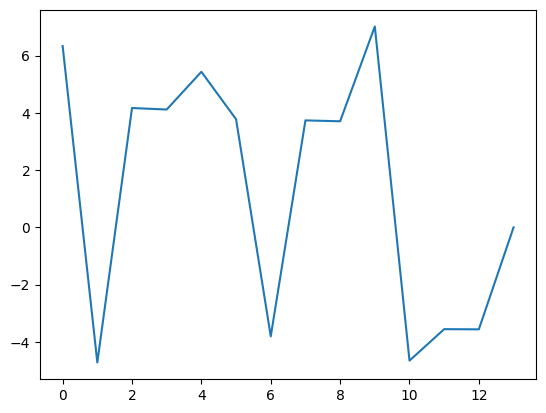

In [ ]:
plt.plot(l2_synth)

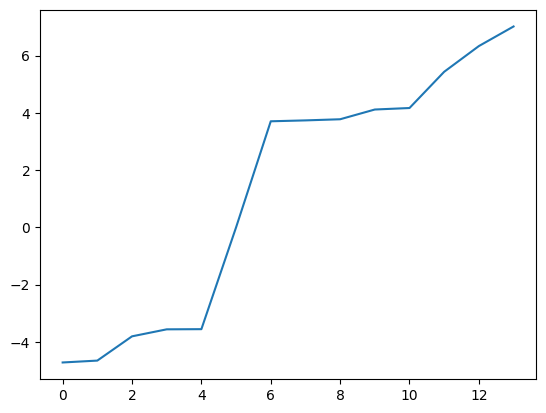

In [ ]:
plt.plot(l2_synth[l2_synth.sort().indices])

In [ ]:
dataset.selected_bits_by_task + 1

tensor([[ 8, 18],
        [23, 27]])

In [ ]:
# sns.heatmap(model.l1.weight.data[l2_synth.sort().indices])

<Axes: >

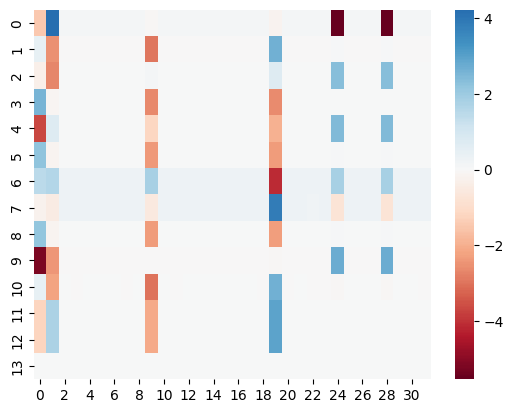

In [ ]:
sns.heatmap(model.l1.weight.data, cmap="RdBu", center=0)

<Axes: >

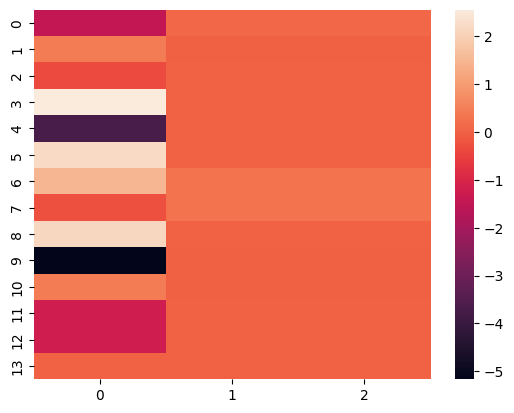

In [ ]:
sns.heatmap(
    model.l1.weight.data[
        :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
    ]
)

In [ ]:
l1_for_task0 = model.l1.weight.data[
    :, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0].sort().values + 1])
]

In [ ]:
F.relu(input=(torch.tensor([1, 0, 0, 0, 0]).float() @ l1_for_task0.T)) @ l2_synth

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x5 and 3x14)

In [ ]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0.T
x3 = F.relu(x2)
x4 = x3 @ l2_synth
x4

tensor([  9.7345,  -9.5743,  -9.5825,   9.6160, -11.2264,   8.4343,   8.4721,
        -12.3207,  -9.6165,   9.7221,   9.5887,  -9.0078,   8.3091,  -9.9947,
        -12.3969,  12.5898])

In [ ]:
F.relu(l1_for_task0[:, 0]) @ l2_synth

tensor(9.7345)

<Axes: >

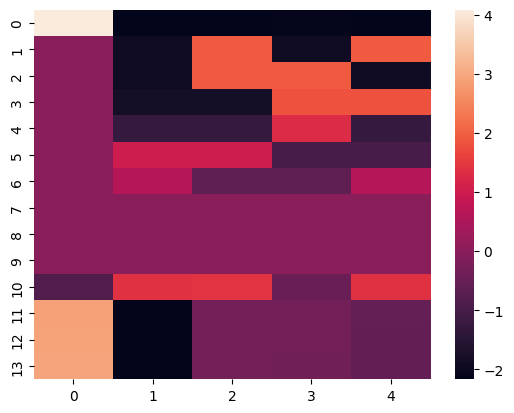

In [ ]:
sns.heatmap(l1_for_task0[l2_synth.sort().indices])

In [ ]:
# neuron_mask = torch.ones(model.l1.out_features).bool()
neuron_mask = ~(model.l1.weight.data.abs().amax(-1) < 1e-14)
assert (l2_synth[~neuron_mask] < 1e-14).all()
(~neuron_mask).sum()

tensor(3)

<Axes: >

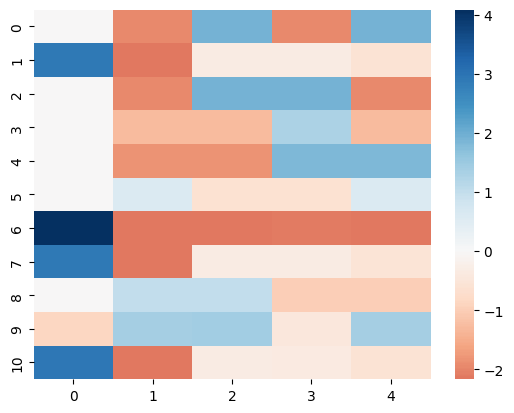

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

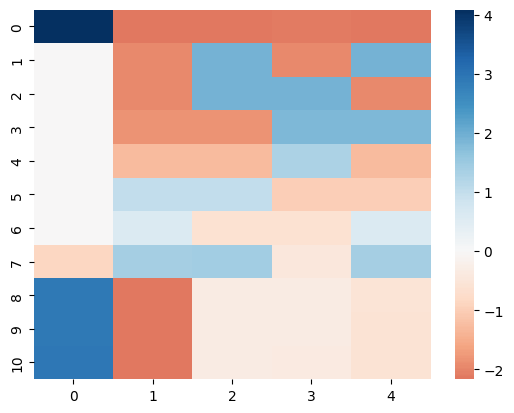

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask][l2_synth[neuron_mask].sort().indices], cmap="RdBu", center=0)

In [ ]:
l2_synth[neuron_mask].sort().indices

tensor([4, 3, 2, 0, 6, 5, 1, 7])

In [ ]:
task_ids = torch.tensor(0).repeat(2**config.n_xored_bits)
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), bits], dim=1).float()
x2 = x1 @ l1_for_task0[neuron_mask].T
x3 = F.relu(x2)
x4 = x3 @ l2_synth[neuron_mask]
x4

tensor([  8.3056, -10.2873, -10.2768,   9.6085, -10.2763,   9.6085,   9.4976,
         -9.4992, -10.2769,   9.6087,   9.4965,  -9.4995,   9.4973,  -9.4990,
        -12.2402,  14.1524])

()

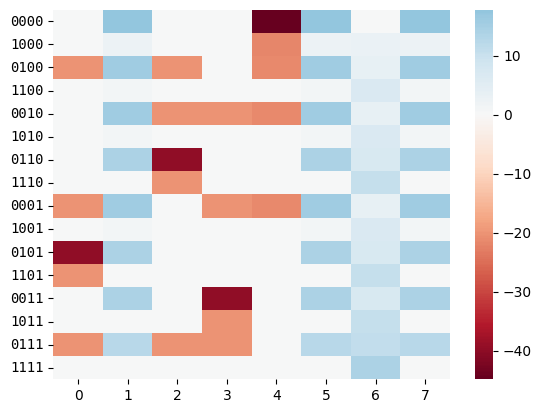

In [ ]:
bit_labels = ["".join(str(b) for b in row) for row in bits.tolist()]
ax = sns.heatmap(x3 * l2_synth[neuron_mask], cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

()

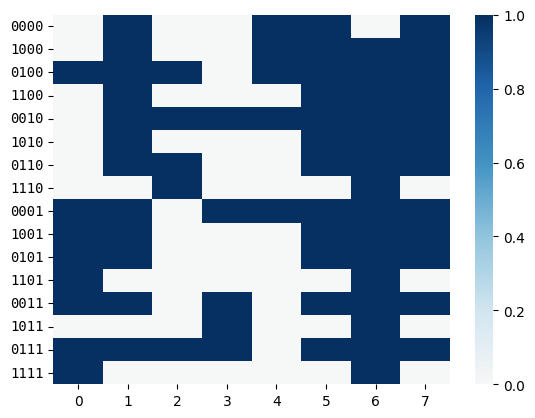

In [ ]:
ax = sns.heatmap(x2 >= 0, cmap="RdBu", center=0)
ax.set_yticks(np.arange(len(bit_labels)) + 0.5)
ax.set_yticklabels(bit_labels, rotation=0, fontfamily="monospace")
()

In [ ]:
l2_synth[neuron_mask]

tensor([ 5.6304, -1.7026, -8.3918, -3.9007, -4.8538, -7.6129, -7.7657,  1.5806,
         5.3819,  7.7784,  8.7952])

In [ ]:
for x in l1_for_task0[neuron_mask][:, 0] / 3.40333 * 16 * 6:
    print(f"{x:.6f}", end=" ")

-0.000004 80.107346 -0.000005 -0.000002 113.371536 79.976242 -1.604484 80.198395 

<Axes: >

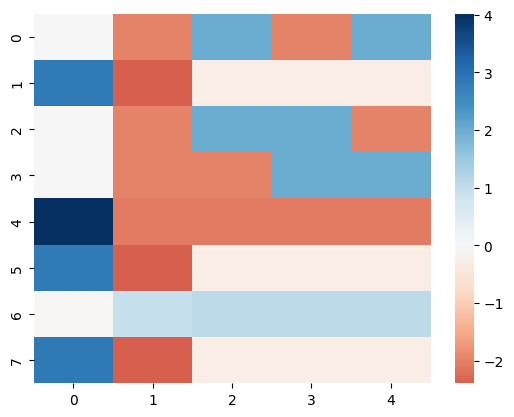

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

<Axes: >

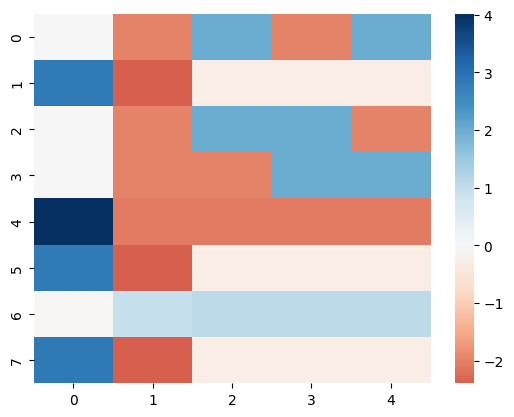

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

()

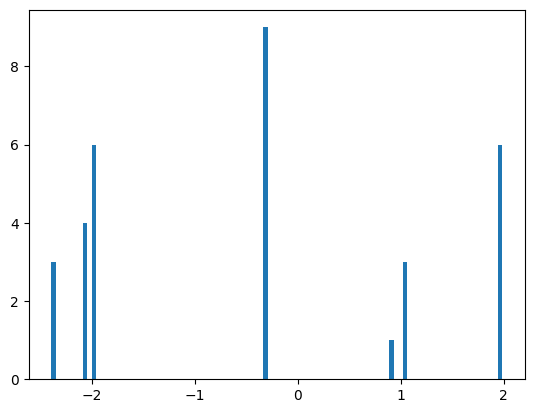

In [ ]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)
()

In [ ]:
(x3 * l2_synth[neuron_mask])

tensor([[ -0.0000,  17.7303,  -0.0000,  -0.0000, -44.8650,  17.6646,   0.0000,
          17.7757],
        [ -0.0000,   2.8015,  -0.0000,  -0.0000, -21.6966,   2.7926,   3.0076,
           2.8075],
        [-19.9370,  15.8910, -19.9364,  -0.0000, -21.5745,  15.8332,   3.5161,
          15.9309],
        [ -0.0000,   0.9622,  -0.0000,  -0.0000,  -0.0000,   0.9613,   6.7223,
           0.9627],
        [ -0.0000,  15.8909, -19.9364, -19.9366, -21.5745,  15.8332,   3.5162,
          15.9308],
        [ -0.0000,   0.9622,  -0.0000,  -0.0000,  -0.0000,   0.9612,   6.7225,
           0.9626],
        [ -0.0000,  14.0516, -39.8728,  -0.0000,  -0.0000,  14.0018,   7.2310,
          14.0860],
        [ -0.0000,   0.0000, -19.9364,  -0.0000,  -0.0000,   0.0000,  10.4372,
           0.0000],
        [-19.9370,  15.8909,  -0.0000, -19.9366, -21.5746,  15.8332,   3.5165,
          15.9308],
        [ -0.0000,   0.9621,  -0.0000,  -0.0000,  -0.0000,   0.9612,   6.7228,
           0.9626],
        [-

()

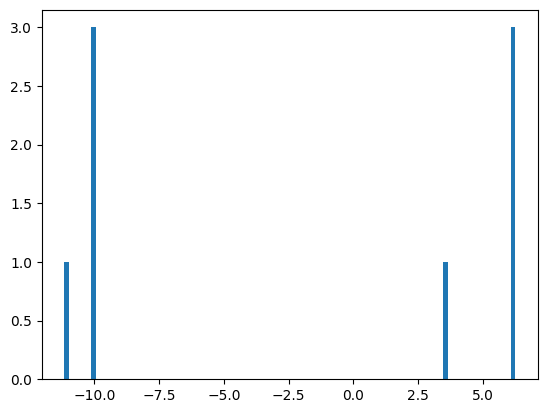

In [ ]:
# plt.hist((l2_synth[neuron_mask].reshape(-1) - 1.6)/4.1, bins=100)
plt.hist((l2_synth[neuron_mask].reshape(-1)), bins=100)
()

In [ ]:
(x3 * l2_synth[neuron_mask]).sum(-1)

tensor([  8.3056, -10.2873, -10.2768,   9.6085, -10.2763,   9.6085,   9.4976,
         -9.4992, -10.2769,   9.6087,   9.4965,  -9.4995,   9.4973,  -9.4990,
        -12.2402,  14.1524])

In [ ]:
logits = (x3 * l2_synth[neuron_mask]).sum(-1)
target = bits.sum(-1) % 2
F.binary_cross_entropy_with_logits(
    -logits, target.float()
)  # .float() as binary_cross_entropy_with_logits supports soft targets

tensor(6.5071e-05)

<Axes: >

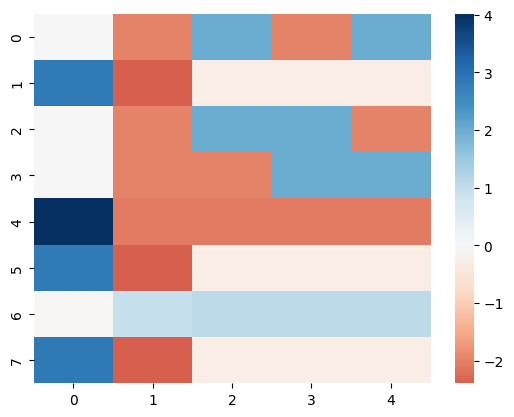

In [ ]:
sns.heatmap(l1_for_task0[neuron_mask], cmap="RdBu", center=0)

In [ ]:
l1_for_task0[neuron_mask][:, 1:].shape

torch.Size([8, 4])

(array([3., 0., 0., 0., 0., 0., 0., 4., 0., 6., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 9., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 3., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 6.]),
 array([-2.39409256, -2.35031962, -2.30654669, -2.26277375, -2.21900105,
        -2.17522812, -2.13145518, -2.08768225, -2.04390931, -2.00013638,
        -1.95636356, -1.91259062, -1.86881781, -1.82504487, -1.78127193,
        -1.737499  , -1.69372606, -1.64995325, -1.60618031, -1.56240749,
        -1.51863456, -1.47486162, -1.43108869, -1.38731575, -1.34354293,
        -1.29977   , -1.25599706, -1.21222425, -1.16845131, -1.12467837,
        -1.08090544, -1.03713262, -0.99335968, -0.94958675, -0.90581393,
        -0.862041  , -0.81826806, -0.77

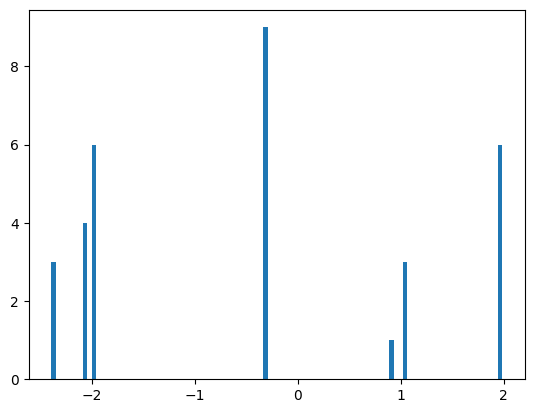

In [ ]:
plt.hist(l1_for_task0[neuron_mask][:, 1:].reshape(-1), bins=100)

In [ ]:
l1_for_task0[neuron_mask][10]

tensor([ 2.4766, -2.4822, -2.4814,  2.4819, -2.4830])

tensor([ 2.8610e-06,  9.5367e-07,  0.0000e+00,  0.0000e+00,  0.0000e+00,
         9.5367e-07,  0.0000e+00,  9.5367e-07,  0.0000e+00,  9.5367e-07,
        -9.5367e-07,  0.0000e+00,  3.8147e-06,  0.0000e+00,  9.5367e-07,
        -9.5367e-07])

In [ ]:
l1_for_task0[neuron_mask].shape

torch.Size([11, 5])

In [ ]:
# plt.plot(l2_synth[neuron_mask].sort().values.abs())

14

In [ ]:
torch.tensor(2, dtype=torch.float).norm(2)

tensor(2.)

<Axes: >

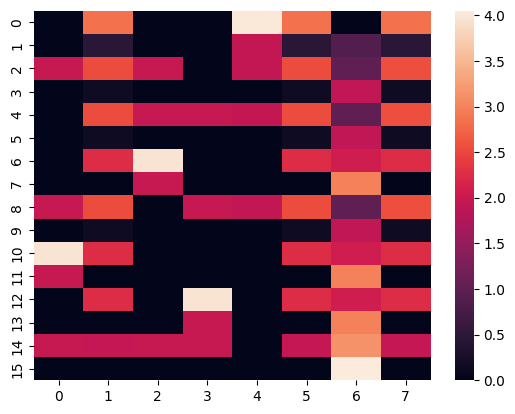

In [ ]:
sns.heatmap(F.relu(input=x2))

<Axes: >

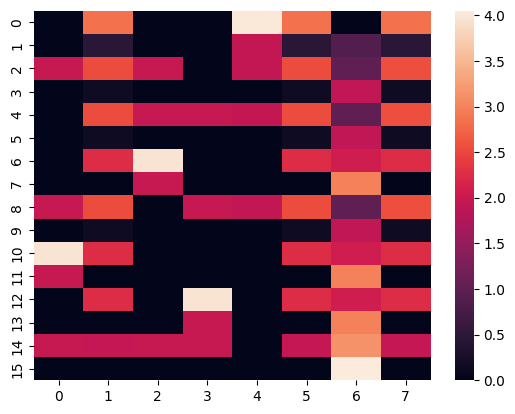

In [ ]:
sns.heatmap(F.relu(input=x2))

In [ ]:
a = F.relu(input=x2) @ ((l2_synth > 0) * 2 - 1).float()
a

tensor([ 0.9016, -2.0912,  0.0547,  0.9204, -1.4292, -0.0093,  1.6414, -0.4008,
        -0.8184, -0.1702,  1.6079, -0.2051,  3.7027, -1.3897, -0.2228,  2.0841])

In [ ]:
(bits.sum(-1) % 2 == 0) == (a > 0)

tensor([ True,  True, False,  True,  True, False,  True,  True,  True, False,
         True,  True,  True,  True,  True,  True])

In [ ]:
bits

tensor([[0, 0, 0, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        [1, 1, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 1, 0],
        [0, 1, 1, 0],
        [1, 1, 1, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 1],
        [0, 1, 0, 1],
        [1, 1, 0, 1],
        [0, 0, 1, 1],
        [1, 0, 1, 1],
        [0, 1, 1, 1],
        [1, 1, 1, 1]])

<Axes: >

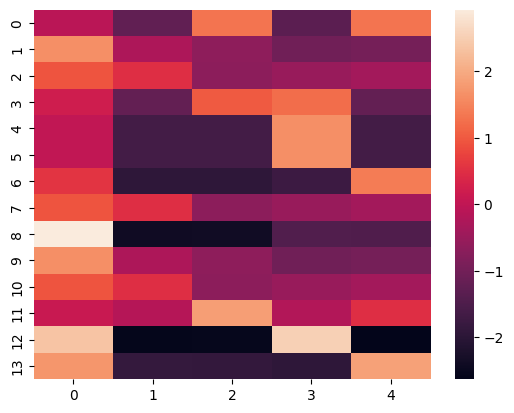

In [ ]:
sns.heatmap(l1_for_task0)

<Axes: >

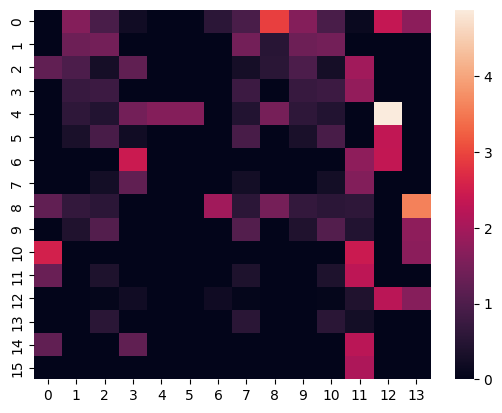

In [ ]:
sns.heatmap(F.relu(input=x2))

<Axes: >

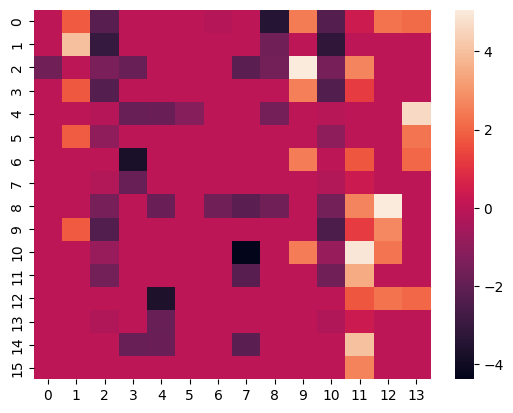

In [ ]:
# sns.heatmap((F.relu(input=x2) * l2_synth))
sns.heatmap((F.relu(input=x2) * ((l2_synth > 0) * 2 - 1)))

In [ ]:
x4

tensor([ 17.6185, -11.8157, -15.4918,  15.6542, -13.2808,  19.9999,  11.8941,
        -15.3787, -15.1771,  15.5628,  18.5022, -15.0493,  11.9677, -15.2677,
        -24.1513,  13.5810])

In [ ]:
model.l1.weight[torch,]

IndexError: index 33 is out of bounds for dimension 0 with size 31

In [ ]:
l2_synth @ model.l1.weight.data[:, 0]

tensor(18.6701)

In [ ]:
x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = model.l2(x3)
x4

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

In [ ]:
batch_sz = 1
task_ids = torch.tensor([0])
bits = torch.tensor([0, 0, 0, 0])
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[0, dataset.selected_bits_by_task[0]] = bits

In [ ]:
task_id = 0
batch_sz = 2**config.n_xored_bits
task_ids = torch.tensor([task_id]).repeat(batch_sz)
# bits = torch.tensor([0,0,0,0])
bits = (
    torch.floor(
        torch.arange(2**config.n_xored_bits).unsqueeze(1) / (2 ** torch.arange(config.n_xored_bits))
    )
    % 2
).long()
task_bits = torch.zeros((batch_sz, config.n_task_bits), dtype=torch.long)
task_bits[:, dataset.selected_bits_by_task[task_id]] = bits

In [ ]:
# l2_synth = model.l2.weight.data[0] - model.l2.weight.data[1]

x1 = torch.cat([F.one_hot(task_ids, model.n_control_bits), task_bits], dim=1).float()
x2 = model.l1(x1)
x3 = F.relu(x2)
x4 = x3 @ l2_synth

x1 = x1.detach()
x2 = x2.detach()
x3 = x3.detach()
x4 = x4.detach()

x4

tensor([ 17.6185, -15.1771, -15.4918,  18.5022, -13.2808,  11.9677,  11.8941,
        -24.1513, -11.8157,  15.5628,  15.6542, -15.0493,  19.9999, -15.2677,
        -15.3787,  13.5810])

In [ ]:
l2_synth @ F.relu(model.l1.weight.data[:, 0])

tensor(17.6185)

<Axes: >

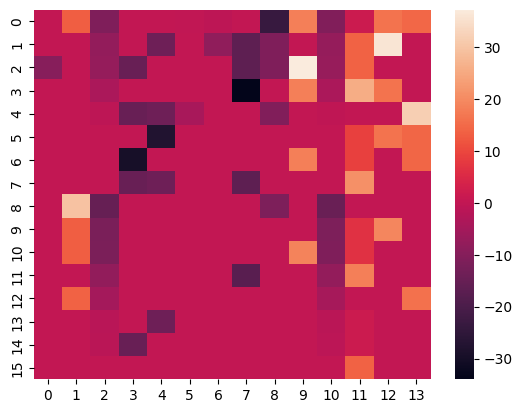

In [ ]:
sns.heatmap((x3 * l2_synth))

In [ ]:
dataset.selected_bits_by_task[0]

tensor([ 7, 17, 21, 16])

In [ ]:
model.l1.weight.data[[17]].shape

torch.Size([1, 40])

<Axes: >

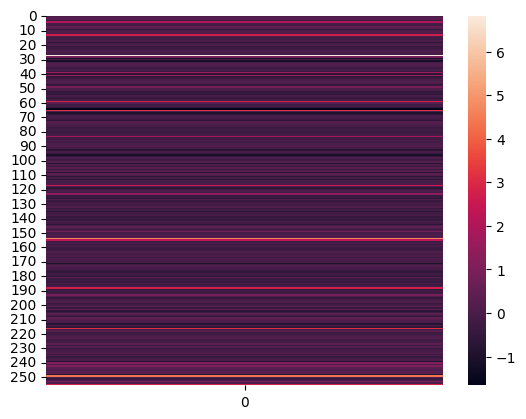

In [ ]:
sns.heatmap(model.l1.weight.data[:, [0]])


<Axes: >

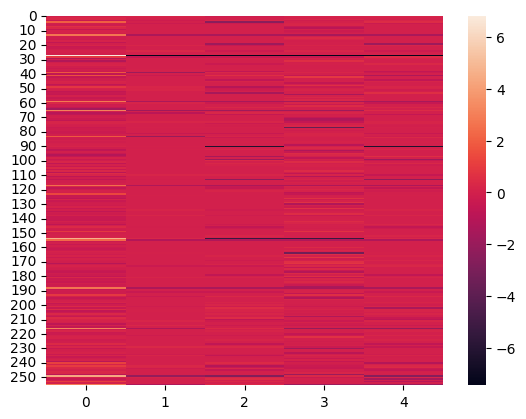

In [ ]:
sns.heatmap(
    model.l1.weight.data[:, torch.cat([torch.tensor([0]), dataset.selected_bits_by_task[0] + 10])]
)

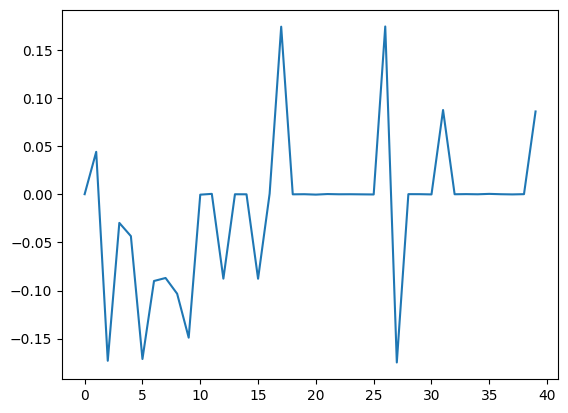

In [ ]:
plt.plot(model.l1.weight.data[0])

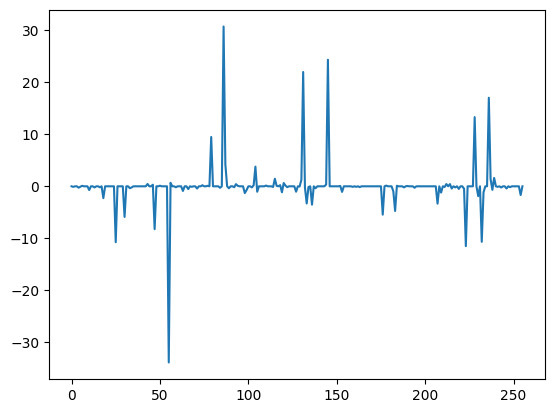

In [ ]:
plt.plot((x3 * l2_synth)[0])
# plt.plot((x3 * l2_synth)[1])
# plt.plot((x3 * l2_synth)[2])
# plt.plot((x3 * l2_synth)[3])
# plt.plot((x3 * l2_synth)[14])
# plt.plot((x3 * l2_synth)[15])

In [ ]:
(x3 * l2_synth)[15].sum()

tensor(9.2621)

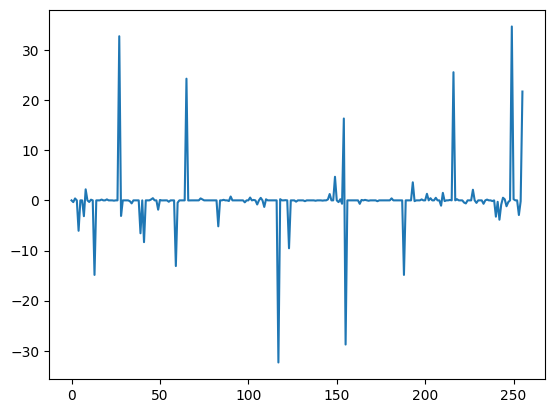

In [ ]:
plt.plot((x3 * l2_synth)[0])

In [ ]:
l2_synth.shape

torch.Size([256])

In [ ]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [ ]:
(x3 @ model.l2.weight.data.T)

tensor([[ 4.2240, -4.2121],
        [-5.3781,  5.3898],
        [-4.9356,  4.9407],
        [ 4.6369, -4.6342],
        [-4.9352,  4.9405],
        [ 4.7689, -4.7663],
        [ 6.7091, -6.7092],
        [-4.5671,  4.5673],
        [-5.2173,  5.2297],
        [ 4.4800, -4.4702],
        [ 4.6336, -4.6305],
        [-5.9108,  5.9139],
        [ 5.7992, -5.7958],
        [-4.2125,  4.2157],
        [-4.5332,  4.5332],
        [ 4.6310, -4.6311]])

In [ ]:
einops.einsum(model.l2.weight.data, x3, 'two '

torch.Size([2, 256])

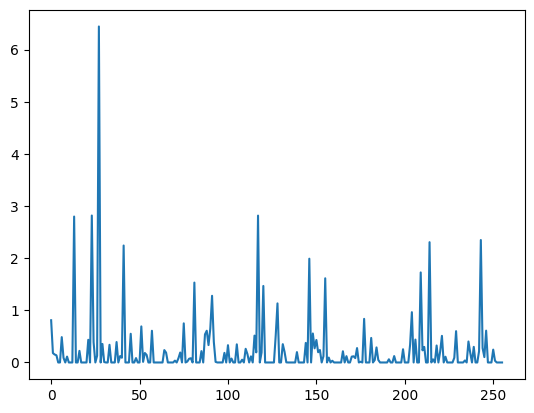

In [ ]:
plt.plot(x3[0])

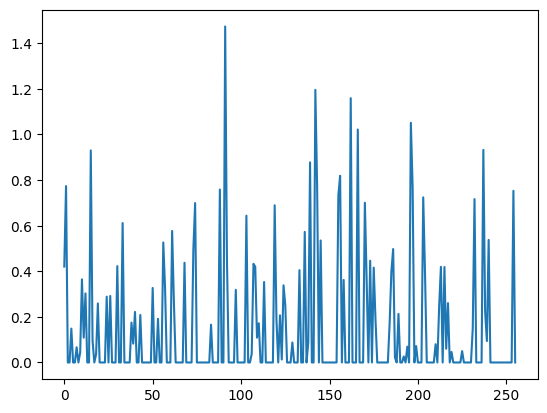

In [ ]:
plt.plot(x3[0].detach())

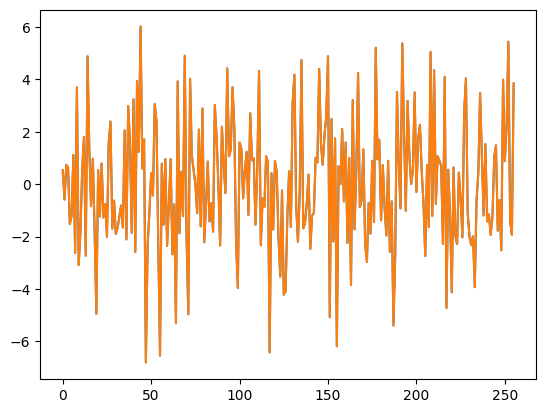

In [ ]:
plt.plot(model.l2.weight.data[0])
plt.plot(-model.l2.weight.data[1])

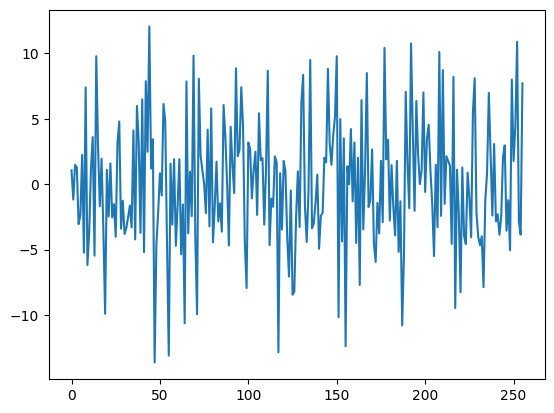

In [ ]:
plt.plot(model.l2.weight.data[0] - model.l2.weight.data[1])

In [ ]:
torch.randint(2, (1, config.n_xored_bits))

tensor([[1, 1, 1, 0]])

In [ ]:
# plt.plot((model.l2.weight.data[0] - model.l2.weight.data[1]))
# plt.plot(model.l1.bias.data)

<Axes: >

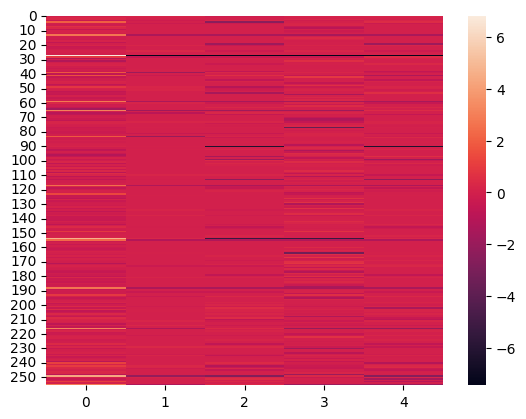

In [ ]:
sns.heatmap(model.l1.weight.data[:, [0, 10 + 7, 10 + 17, 10 + 21, 10 + 16]])

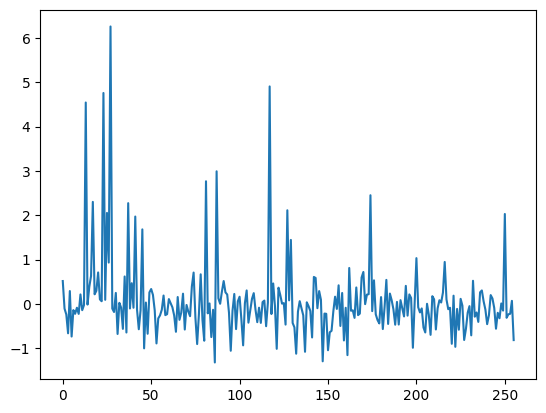

In [ ]:
plt.plot(model.l1.weight.data[:, 0])

<Axes: >

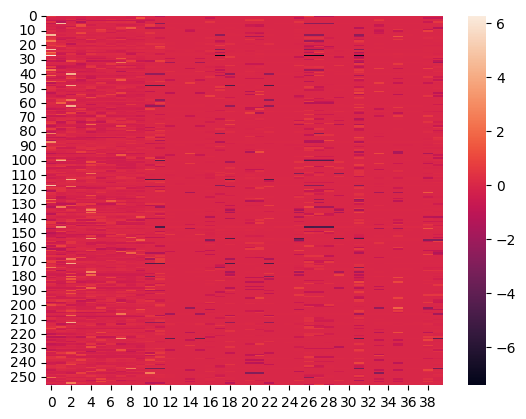

In [ ]:
sns.heatmap(model.l1.weight.data)

In [ ]:
(torch.arange(10, dtype=torch.float) + 1) ** -(0.4)

tensor([1.0000, 0.7579, 0.6444, 0.5743, 0.5253, 0.4884, 0.4592, 0.4353, 0.4152,
        0.3981])

In [ ]:
(torch.arange(10, dtype=torch.float) + 1) ** -(1 + 0.4)

tensor([1.0000, 0.3789, 0.2148, 0.1436, 0.1051, 0.0814, 0.0656, 0.0544, 0.0461,
        0.0398])